Regression Model Python - 6/19/2026 - DAMHAR2570

In [1]:
# Import necessary libraries
import pandas as pd
from sklearn.datasets import fetch_california_housing
from datetime import datetime
from IPython.display import display, Markdown
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "DAMHAR2570"

# Load the California Housing dataset
california_housing = fetch_california_housing(as_frame=True)
data = california_housing.frame

# Display the first few rows to understand what the data looks like
display(Markdown("### Step 1.2: Load the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
display(data.head())

### Step 1.2: Load the Dataset

Date: 2026-06-19

Student ID: DAMHAR2570

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
display(Markdown("### Step 1.3: Initial Exploration of the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Get a concise summary of the DataFrame
print(data.info())

# Get descriptive statistics that summarize the central tendency, dispersion, and shape of the dataset's numerical features
display(data.describe())

### Step 1.3: Initial Exploration of the Dataset

Date: 2026-06-19

Student ID: DAMHAR2570

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
display(Markdown("### Step 1.4: Data Cleaning"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Check for missing values in the dataset
missing_values = data.isnull().sum()
print(f"Missing values in each column:\n{missing_values}")

# Assuming the decision is to fill missing numerical values with the median
for column in data.select_dtypes(include=['number']).columns:
    data[column].fillna(data[column].median())

### Step 1.4: Data Cleaning

Date: 2026-06-19

Student ID: DAMHAR2570

Missing values in each column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [5]:
display(Markdown("### Step 1.5: Feature Selection"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Selecting all features for this task
selected_features = data.drop(columns=['MedHouseVal'])
target = data['MedHouseVal']

# Display the first few rows of the selected features to verify
display(selected_features.head())

### Step 1.5: Feature Selection

Date: 2026-06-19

Student ID: DAMHAR2570

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [6]:
display(Markdown("### Step 2.1: Data Splitting"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
from sklearn.model_selection import train_test_split

# Preparing features (X) and target variable (y) from the prepared dataset
X = selected_features
y = target

# Splitting the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the sizes of the training and test sets to verify the split
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

### Step 2.1: Data Splitting

Date: 2026-06-19

Student ID: DAMHAR2570

Training set size: 16512 samples
Test set size: 4128 samples


In [7]:
display(Markdown("### Step 2.2: Model Training"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Import the regressor model
from sklearn.ensemble import GradientBoostingRegressor

# Instantiate and train the gradient boosting regression model
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)
print("Model training completed.")

### Step 2.2: Model Training

Date: 2026-06-19

Student ID: DAMHAR2570

Model training completed.


### Step 2.3: Model Evaluation

Date: 2026-06-19

Student ID: DAMHAR2570

Mean Squared Error: 0.2939973248643864
R² Score: 0.7756446042829697


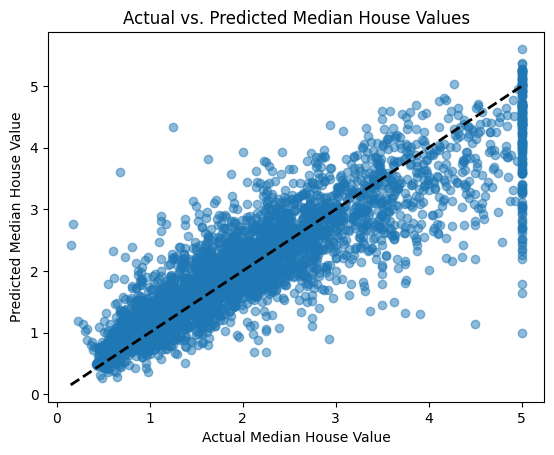

In [8]:
display(Markdown("### Step 2.3: Model Evaluation"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Making predictions with the testing set
y_pred = model.predict(X_test)

# Calculate and print evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

# Visualization of actual vs. predicted values
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('Actual vs. Predicted Median House Values')
plt.show()

### Step 3.1: Predicting with Early Stopping

Date: 2026-06-19

Student ID: DAMHAR2570


Mean Squared Error on New Data: 0.29162405498317995
R² Score on New Data: 0.7774556952634302


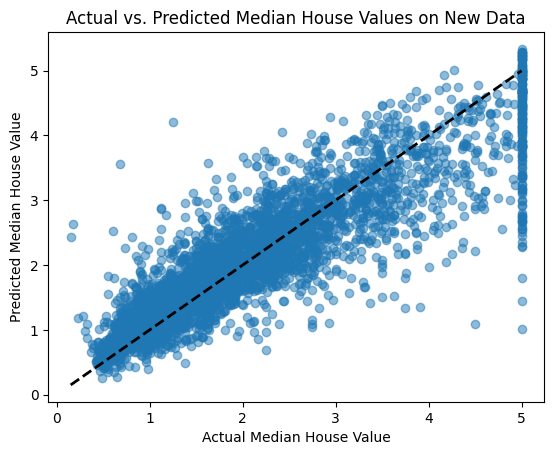

In [9]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
display(Markdown("### Step 3.1: Predicting with Early Stopping"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Split the training data further to create a validation set for early stopping
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

# Instantiate and train the gradient boosting regression model with early stopping
model = GradientBoostingRegressor(random_state=42, n_iter_no_change=10, validation_fraction=0.1)
model.fit(X_train, y_train)

# Using the test set as new, unseen data
y_new_pred = model.predict(X_test)

# Calculating evaluation metrics for new data predictions
mse_new = mean_squared_error(y_test, y_new_pred)
r2_new = r2_score(y_test, y_new_pred)
print(f"\nMean Squared Error on New Data: {mse_new}")
print(f"R² Score on New Data: {r2_new}")

# Visualizing actual vs. predicted values on new data
plt.scatter(y_test, y_new_pred, alpha=0.5)
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('Actual vs. Predicted Median House Values on New Data')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()

### Step 3.2: Analyzing Residuals

Date: 2026-06-19

Student ID: DAMHAR2570

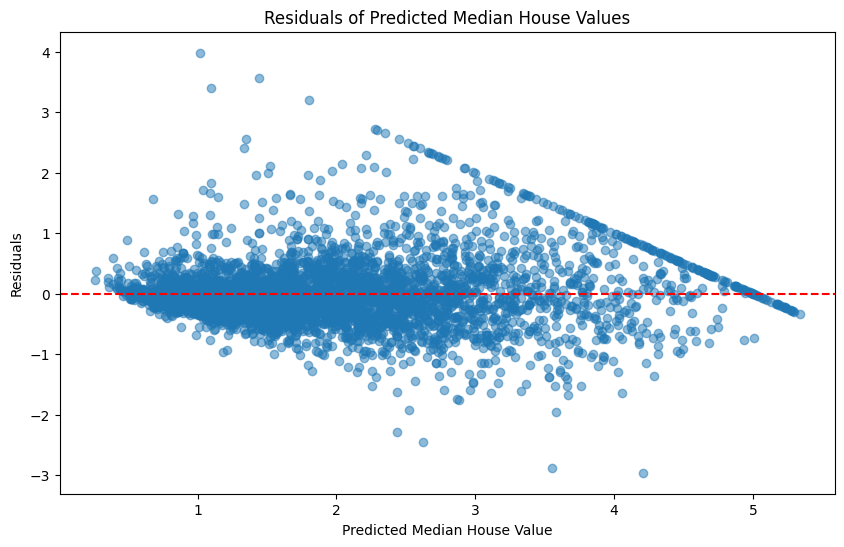

In [10]:
display(Markdown("### Step 3.2: Analyzing Residuals"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Calculate residuals
residuals = y_test - y_new_pred

# Plotting the residuals
plt.figure(figsize=(10, 6))
plt.scatter(y_new_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Median House Value')
plt.ylabel('Residuals')
plt.title('Residuals of Predicted Median House Values')
plt.show()